In [32]:
import sys
sys.path.append("..")
import os

import torch
import numpy as np
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score,
)
from tqdm import tqdm

from src.models.base_models import create_model
from src.models.domain_discriminator import DomainDiscriminator
from src.data.numu_dataset import NuMuDataset, create_numu_dataloader_from_ds

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Signal Efficiency & Background Suppression
**Experiment:** `da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr`

Three positive-label cases:
1. Both atmospheric (`nuatm`) + astrophysical (`nue2`) neutrinos as signal — balanced
2. Only astrophysical (`nue2`) as signal
3. Only atmospheric (`nuatm`) as signal

Each case shows two twinx panels over the classification threshold:
- **Left** — TPR (signal efficiency, solid) and 1/FPR (background suppression, dashed, log scale)
- **Right** — Precision (solid) and Recall (dashed)

In [33]:
EXPERIMENT_DIR = Path("../experiments/numu/da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr")
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

report_dir = EXPERIMENT_DIR / "report_PR_curves"
os.makedirs(report_dir, exist_ok=True)

print(f"Experiment: {EXPERIMENT_DIR.name}")
print(f"Device:     {DEVICE}")
print(f"Report dir: {report_dir}")

Experiment: da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr
Device:     cuda:0
Report dir: ../experiments/numu/da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr/report_PR_curves


## 1. Load model

In [34]:
with open(EXPERIMENT_DIR / "da_config.yaml") as f:
    config = yaml.safe_load(f)
with open(EXPERIMENT_DIR / "normalization_config.yaml") as f:
    normalization_config = yaml.safe_load(f)

print(f"Model d_model: {config['model']['feature_extractor']['d_model']}")
print(f"Max hits:      {config['data']['max_hits']}")
print(f"Seed:          {config['experiment']['seed']}")

Model d_model: 64
Max hits:      500
Seed:          42


In [35]:
checkpoint = torch.load(EXPERIMENT_DIR / "best_da_model.pth", map_location=DEVICE, weights_only=False)

model = create_model(config['model'])
model.load_state_dict(checkpoint['base_model_state_dict'])
model.to(DEVICE).eval()

print(f"Loaded checkpoint — epoch {checkpoint.get('epoch')}, best metric {checkpoint.get('best_metric'):.4f}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loaded checkpoint — epoch 40, best metric 0.9782
Model parameters: 53,633


## 2. Load test data (source domain, held-out portion)

In [36]:
source_cfg = config['data']['source_domain']
train_counts = source_cfg['events_per_particle']  # {muatm: 300k, nuatm: 150k, nue2: 150k}

TEST_N = 100_000  # events per particle type

test_dataset = NuMuDataset(
    h5_path=source_cfg['h5_path'],
    events_per_particle={p: TEST_N for p in train_counts},
    particle_types=source_cfg['particle_types'],
    neutrino_types=source_cfg['neutrino_types'],
    max_hits=config['data']['max_hits'],
    sampling_config={
        p: {'mode': 'range', 'start_event': n}
        for p, n in train_counts.items()
    },
    device='cpu',
    shuffle_events=False,
)

test_dataloader = create_numu_dataloader_from_ds(
    dataset=test_dataset,
    batch_size=512,
    normalization_config=normalization_config,
    augmentation_config=None,
    shuffle=False,
    shuffle_batch=False,
    num_workers=0,
)

print(f"Test dataset: {len(test_dataset):,} events")

Test dataset: 300,000 events


## 3. Run inference

In [37]:
all_probs = []
all_magic_numbers = []
all_channels_ids = []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Inference"):
        feat = model.get_feature_representation(
            {k: v.to(DEVICE) if hasattr(v, 'to') else v for k, v in batch.items()}
        )
        logits = model.classifier(feat)
        all_probs.append(torch.sigmoid(logits).cpu().numpy().flatten())
        all_magic_numbers.append(batch['magic_numbers'])
        all_channels_ids.append(batch['channels_ids'])

probs = np.concatenate(all_probs)

# Metadata comes directly from the dataset (order preserved with shuffle=False, shuffle_batch=False)
labels      = np.array([l.item() if hasattr(l, 'item') else bool(l) for l in test_dataset.labels], dtype=bool)
signal_hits = np.array([(mn != 0).sum() for mn in test_dataset.magic_numbers])
ptypes      = np.array([eid.split(':')[0] for eid in test_dataset.event_ids])
magic_numbers = []
for values in all_magic_numbers:
    magic_numbers += values
channels_ids = []
for values in all_channels_ids:
    channels_ids += values
signal_string_nums = np.asarray([np.unique(ids[numbers!=0]//36).size for numbers, ids in zip(magic_numbers, channels_ids)])

print(f"Total events:    {len(probs):,}")
print(f"Signal (nu):     {labels.sum():,}")
print(f"Background (mu): {(~labels).sum():,}")
for pt in np.unique(ptypes):
    n = (ptypes == pt).sum()
    is_nu = labels[ptypes == pt].sum()
    print(f"  {pt}: {n:,}  (nu={is_nu:,})")

Inference: 100%|██████████| 586/586 [00:11<00:00, 51.13it/s]


Total events:    300,000
Signal (nu):     200,000
Background (mu): 100,000
  muatm_2020: 100,000  (nu=0)
  nuatm_2020: 100,000  (nu=100,000)
  nue2_2020: 100,000  (nu=100,000)


## 4. Plots

**Quality cuts** applied symmetrically to **both** signal and background events:
- `h=0` — no cut, all events
- `h≥8, s≥2` — `signal_hits >= 8` **and** `signal_string_nums >= 2` for every event (muons included)

**Case 1 balancing**: 200k positives (nuatm + nue2) subsampled once to 100k to match 100k muons; cuts then reduce both pools further.

Each panel: **TPR** (solid, left y) and **1/FPR** (dashed, right y, log) vs classification threshold.
Dotted vertical line marks the threshold where **TPR = 99%** for the `h≥8, s≥2` cut, with the suppression value annotated.


In [179]:
HIT_CUTS   = [0,   8]
CUT_COLORS = ['grey', None]
CUT_LABELS = ['No cuts', 'hits≥8, strings≥2']

SUPP_CLIP = 10_000  # clip 1/FPR to this maximum for display

bg_mask = ~labels  # muon background

# Reference cut for the vertical line: h>=8, s>=2, TPR=99%
REF_H = 8
REF_TPR_TARGET = 0.99


def make_pr_mask(
    h: int,
    positive_mask: np.ndarray,
    subsample_mask: np.ndarray | None = None,
) -> np.ndarray:
    """
    Apply the same quality cut to BOTH signal and background events.
    h=0  : no cut — all events included.
    h>0  : keep only events with signal_hits >= h AND signal_string_nums >= 2.
    subsample_mask: optional pre-filter on the positive pool only (class balancing).
    """
    base_pos = positive_mask if subsample_mask is None else (positive_mask & subsample_mask)

    if h > 0:
        quality  = (signal_hits >= h) & (signal_string_nums >= 2)
        sig_keep = base_pos & quality
        bg_keep  = bg_mask  & quality
    else:
        sig_keep = base_pos
        bg_keep  = bg_mask

    return bg_keep | sig_keep


def relabeled_labels(mask: np.ndarray, positive_mask: np.ndarray) -> np.ndarray:
    return positive_mask[mask].astype(int)


def balanced_subsample_mask(positive_mask: np.ndarray, seed: int = 42) -> np.ndarray:
    """Subsample positives down to the number of background events (h=0 count)."""
    n_neg   = int(bg_mask.sum())
    pos_idx = np.where(positive_mask)[0]
    chosen  = np.random.default_rng(seed).choice(pos_idx, size=n_neg, replace=False)
    m = np.zeros(len(probs), dtype=bool)
    m[chosen] = True
    return m


def get_ref_threshold(positive_mask: np.ndarray, subsample_mask: np.ndarray | None = None):
    """
    Compute the classification threshold where TPR ≈ REF_TPR_TARGET
    using the REF_H quality cut (h>=REF_H, s>=2).
    Returns (threshold, suppression_at_threshold).
    """
    mask    = make_pr_mask(REF_H, positive_mask, subsample_mask)
    y_true  = relabeled_labels(mask, positive_mask)
    y_score = probs[mask]

    fpr_arr, tpr_arr, thr_arr = roc_curve(y_true, y_score)
    thr_arr = thr_arr[1:][::-1]
    tpr_arr = tpr_arr[1:][::-1]
    fpr_arr = fpr_arr[1:][::-1]
    inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)

    # Find first index where TPR drops to or below REF_TPR_TARGET (threshold increasing)
    idx = np.searchsorted(-(tpr_arr), -REF_TPR_TARGET)
    idx = min(idx, len(thr_arr) - 1)
    return float(thr_arr[idx]), float(inv_fpr[idx])


# ── TPR & 1/FPR vs threshold (twinx) ────────────────────────────────────────
def plot_tpr_suppression_panel(
    ax_tpr,
    positive_mask: np.ndarray,
    title: str,
    subsample_mask: np.ndarray | None = None,
) -> plt.Axes:
    """
    Left y-axis  (ax_tpr):   TPR / signal efficiency        — solid lines.
    Right y-axis (ax_supp):  1/FPR / background suppression — dashed lines, log scale, clipped at SUPP_CLIP.
    Two separate legends: left for TPR curves + vline, right for 1/FPR curves.
    Returns the twin Axes.
    """
    ax_supp = ax_tpr.twinx()
    ax_supp.set_yscale('log')

    tpr_line_handles  = []  # for left legend
    supp_line_handles = []  # for right legend

    for h, color, lbl in zip(HIT_CUTS, CUT_COLORS, CUT_LABELS):
        mask    = make_pr_mask(h, positive_mask, subsample_mask)
        y_true  = relabeled_labels(mask, positive_mask)
        print(y_true.sum(), y_true.shape)
        y_score = probs[mask]
        if y_true.sum() == 0 or (~y_true.astype(bool)).sum() == 0:
            continue

        auc_val = roc_auc_score(y_true, y_score)
        fpr_arr, tpr_arr, thr_arr = roc_curve(y_true, y_score)

        # sklearn prepends an artificial (0,0) point at threshold > max_score; drop it
        thr_arr = thr_arr[1:][::-1]
        tpr_arr = tpr_arr[1:][::-1]
        fpr_arr = fpr_arr[1:][::-1]

        inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
        inv_fpr = np.clip(inv_fpr, None, SUPP_CLIP)
        clip = (thr_arr >= 0) & (thr_arr <= 1)

        tpr_line, = ax_tpr.plot(thr_arr[clip], tpr_arr[clip],
                                 color=color, linewidth=2.0, linestyle='-')
        supp_line, = ax_supp.plot(thr_arr[clip], inv_fpr[clip],
                                   color=color, linewidth=2.0, linestyle='--')

        tpr_line_handles.append(
            Line2D([0], [0], color=color, lw=2, ls='-', label=f'{lbl}')
        )
        supp_line_handles.append(
            Line2D([0], [0], color=color, lw=2, ls='--', label=lbl)
        )

    # ── Reference vertical line at TPR=99% for h>=REF_H, s>=2 ──────────────
    ref_thr, ref_supp = get_ref_threshold(positive_mask, subsample_mask)
    ref_color = 'red'#CUT_COLORS[HIT_CUTS.index(REF_H)]
    ref_supp_clipped = min(ref_supp, SUPP_CLIP)

    ax_tpr.axvline(ref_thr, color=ref_color, linewidth=1.4, linestyle=':')
    tpr_line_handles.append(
        Line2D([0], [0], color=ref_color, lw=1.4, ls=':',
               label=f'Saving {int(REF_TPR_TARGET*100)}% ν @ thr={ref_thr:.3f}')
    )

    # Annotate suppression value on the right y-axis
    ax_supp.annotate(
        f'Supp={ref_supp:.0f}',
        xy=(ref_thr, ref_supp_clipped),
        xytext=(ref_thr - 0.21, ref_supp_clipped),
        fontsize=11, color=ref_color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=ref_color, lw=1.2),
        va='center',
    )

    ax_tpr.set_xlim(0, 1)
    ax_tpr.set_ylim(0, 1.02)
    ax_supp.set_ylim(bottom=1)
    ax_tpr.set_xlabel('Classification threshold', fontsize=12)
    ax_tpr.set_ylabel(r'${\nu}$ Efficiency ( TPR )', fontsize=11)
    ax_supp.set_ylabel(r'EAS Suppression ( $FPR^{-1}$ )', fontsize=11)
    ax_tpr.set_title(title, fontsize=12)

    ax_tpr.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax_tpr.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax_tpr.grid(which='major', alpha=0.3)
    ax_tpr.grid(which='minor', alpha=0.12)

    # Left legend — TPR curves + vertical reference line
    ax_tpr.legend(handles=tpr_line_handles,
                  fontsize=8.5, loc=(0.01, 0.75), framealpha=0.85,
                  title='Efficiency (solid)', title_fontsize=8.5)

    # Right legend — 1/FPR curves, attached to ax_supp
    ax_supp.legend(handles=supp_line_handles,
                   fontsize=8.5, loc=(0.7, 0.35), framealpha=0.85,
                   title='Suppression (dashed)', title_fontsize=8.5)

    return ax_supp


### Case 1 — Both nuatm + nue2 as signal

Case 1 balanced: 100,000 positives / 100,000 negatives
100000 (200000,)
29088 (51834,)


/tmp/ipykernel_14687/3630946832.py:109: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_14687/3630946832.py:109: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_14687/3630946832.py:66: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)


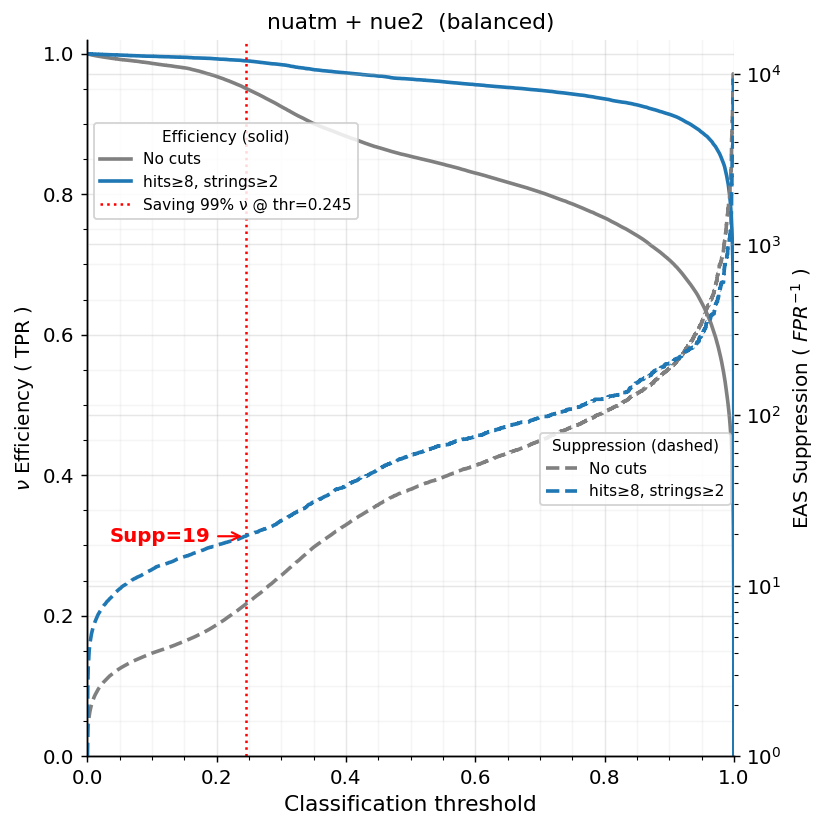

In [180]:
pos_both = labels.copy()  # both nuatm and nue2 are positive

# Subsample positives to match background count (200k → 100k)
sub_both = balanced_subsample_mask(pos_both)
print(f"Case 1 balanced: {(pos_both & sub_both).sum():,} positives / {bg_mask.sum():,} negatives")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
plot_tpr_suppression_panel(ax, pos_both,
    title='nuatm + nue2  (balanced)',
    subsample_mask=sub_both)
fig.tight_layout()
fig.savefig(report_dir / "tpr_supp_both_nu.png", dpi=150, bbox_inches='tight')
plt.show()


### Case 2 — Only astrophysical (nue2) as signal

100000 (200000,)
51896 (74642,)


/tmp/ipykernel_14687/3630946832.py:109: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_14687/3630946832.py:109: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_14687/3630946832.py:66: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)


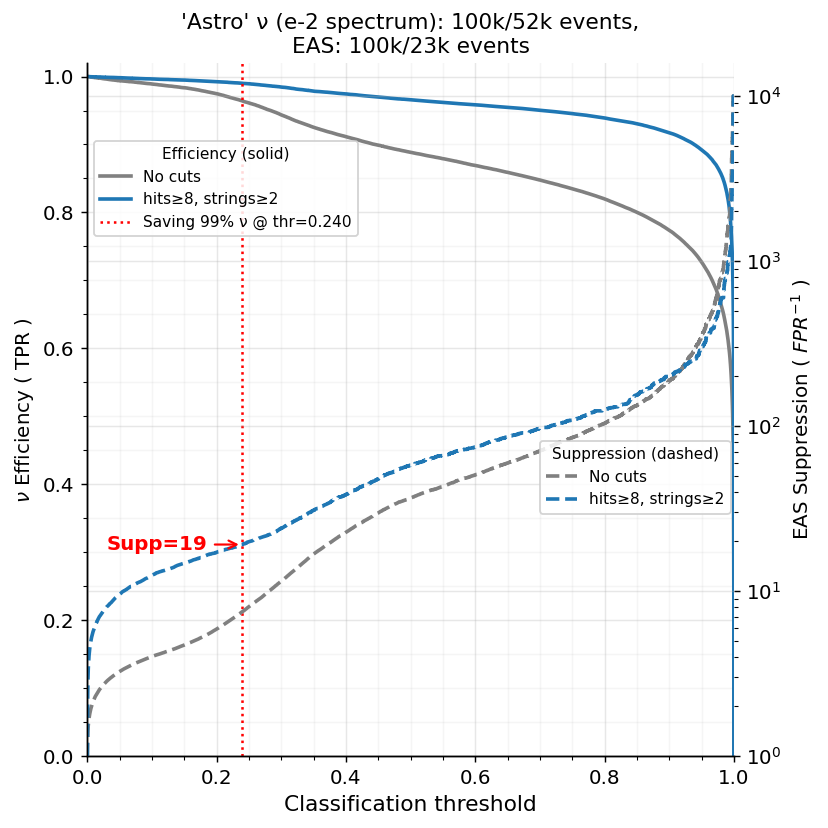

In [181]:
pos_nue2 = (ptypes == 'nue2_2020') & labels

fig, ax = plt.subplots(figsize=(6.5, 6.5))
plot_tpr_suppression_panel(ax, pos_nue2,
    title="'Astro' ν (e-2 spectrum): 100k/52k events,\nEAS: 100k/23k events")
fig.tight_layout()
fig.savefig(report_dir / "tpr_supp_nue2_only.png", dpi=150, bbox_inches='tight')
plt.show()


### Case 3 — Only atmospheric (nuatm) as signal

100000 (200000,)
6495 (29241,)


/tmp/ipykernel_14687/3630946832.py:109: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_14687/3630946832.py:109: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_14687/3630946832.py:66: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)


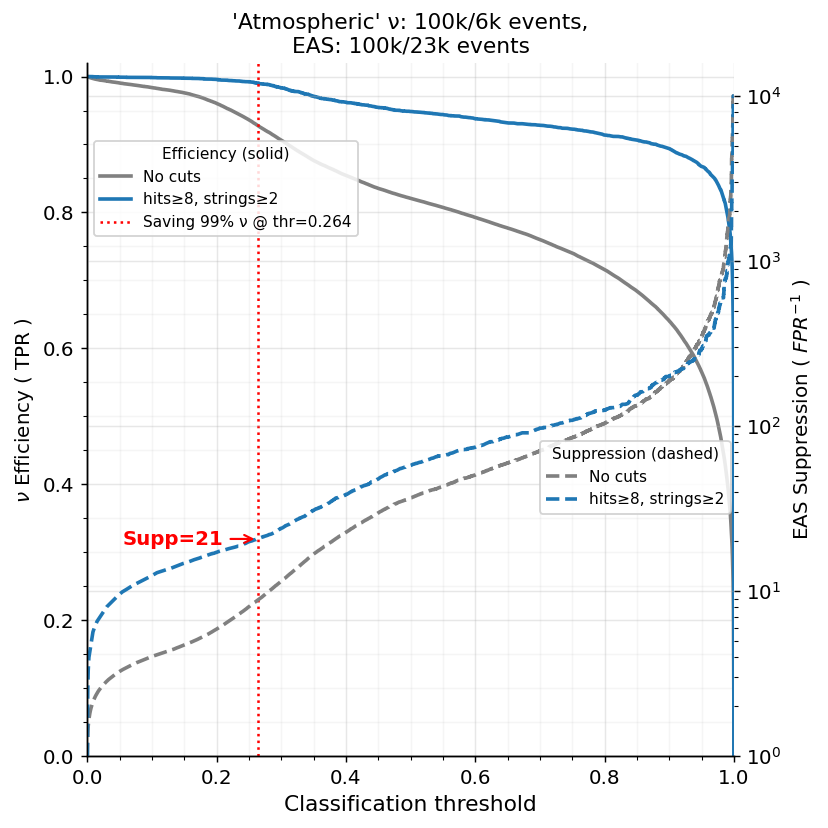

In [182]:
pos_nuatm = (ptypes == 'nuatm_2020') & labels

fig, ax = plt.subplots(figsize=(6.5, 6.5))
plot_tpr_suppression_panel(ax, pos_nuatm,
    title="'Atmospheric' ν: 100k/6k events,\nEAS: 100k/23k events")
fig.tight_layout()
fig.savefig(report_dir / "tpr_supp_nuatm_only.png", dpi=150, bbox_inches='tight')
plt.show()


### Combined: all 3 cases side by side

/tmp/ipykernel_14687/661632895.py:108: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_14687/661632895.py:108: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_14687/661632895.py:66: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_14687/661632895.py:108: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_14687/661632895.py:108: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_14687/661632895.py:66: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_14687/661632895.py:108: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.w

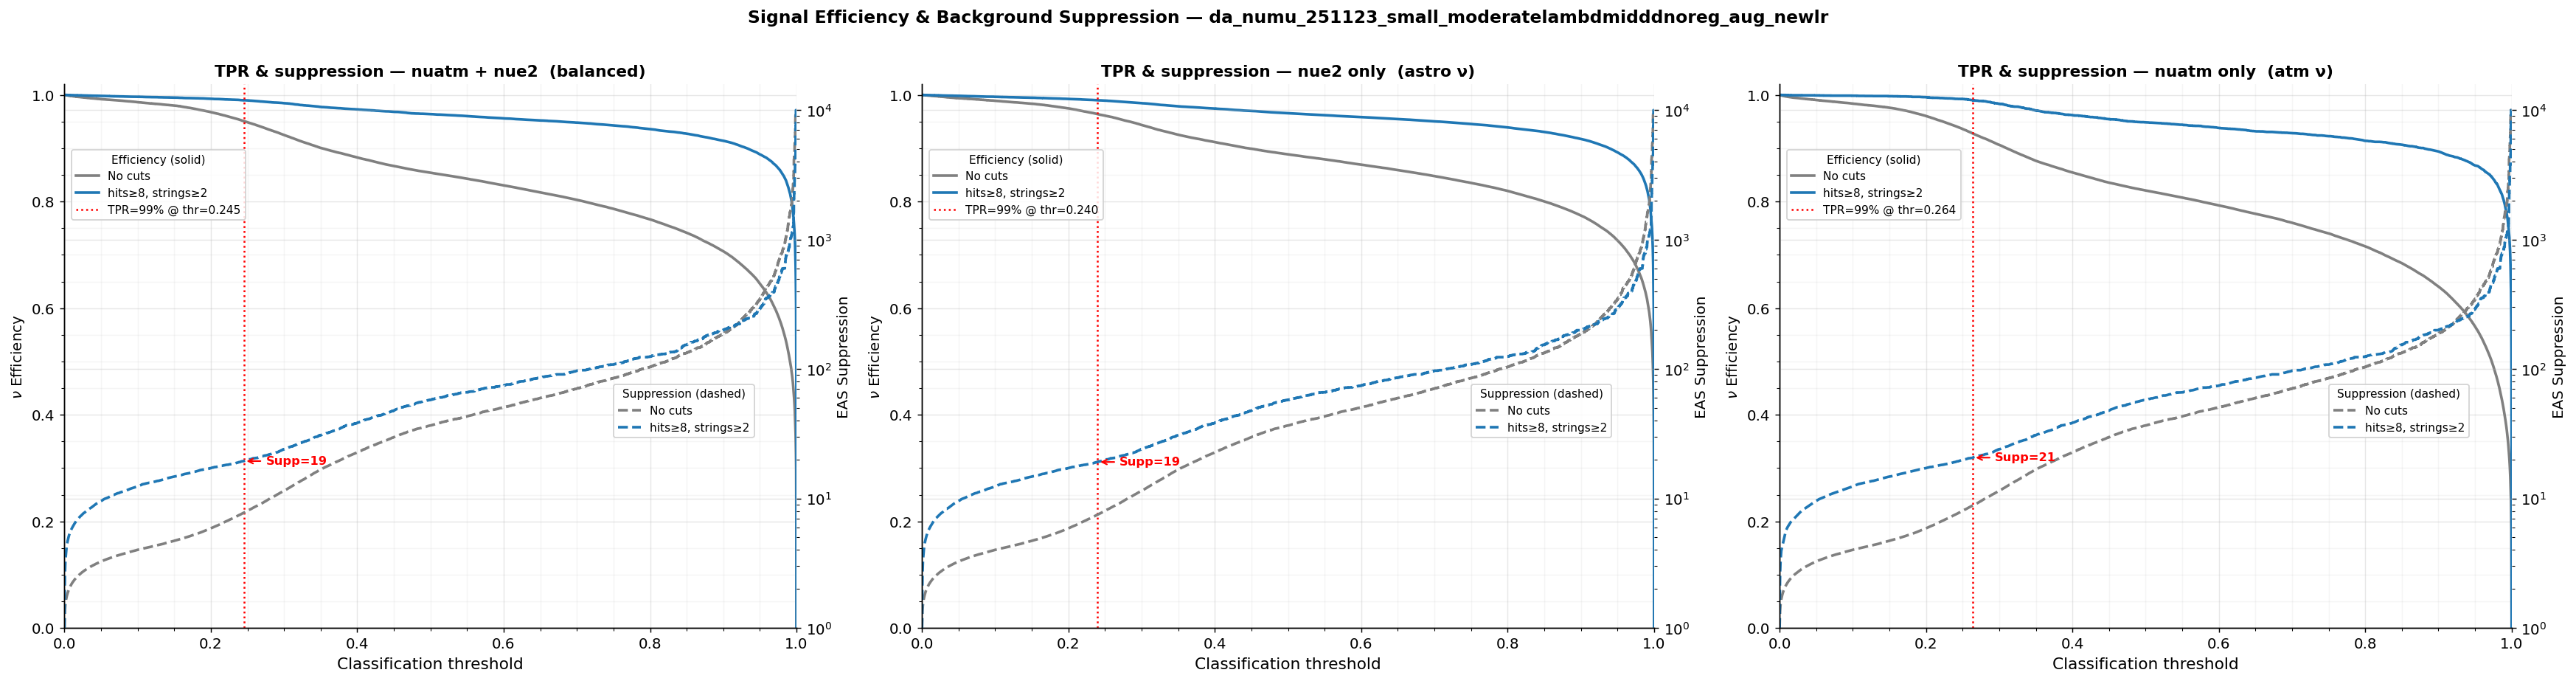

All figures saved to: ../experiments/numu/da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr/report_PR_curves


In [114]:
# Combined 3×1 figure: one TPR/suppression panel per case
fig, axes = plt.subplots(1, 3, figsize=(27, 7))

cases = [
    (pos_both,  sub_both, 'nuatm + nue2  (balanced)'),
    (pos_nue2,  None,     'nue2 only  (astro ν)'),
    (pos_nuatm, None,     'nuatm only  (atm ν)'),
]

for col, (pos_mask, sub_mask, case_lbl) in enumerate(cases):
    plot_tpr_suppression_panel(axes[col], pos_mask,
        title=f'TPR & suppression — {case_lbl}',
        subsample_mask=sub_mask)

fig.suptitle(
    f'Signal Efficiency & Background Suppression — {EXPERIMENT_DIR.name}',
    fontsize=13, fontweight='bold', y=1.01,
)
fig.tight_layout()
fig.savefig(report_dir / "tpr_supp_all_cases.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"All figures saved to: {report_dir}")
